# Customer Feedback Intelligence — NLP Pipeline
### Yelp Review Full dataset — Tasks 1, 2, 3 & 5

**Dataset:** Yelp Review Full (Yelp/yelp_review_full), Hugging Face Datasets.
Zhang, X., Zhao, J. and LeCun, Y. (2015) *Character-level Convolutional Networks for
Text Classification*. Advances in Neural Information Processing Systems 28.
Dataset link: https://huggingface.co/datasets/Yelp/yelp_review_full

**Scope of this notebook:** Task 1 (Preprocessing & EDA), Task 2 (Classical NLP Baseline),
Task 3 (Semantic Embeddings), and Task 5 (Responsible NLP, Risks & Mitigation).
**Task 4 (transformer fine-tuning) is handled separately** in its own notebook/pipeline.

> Run top-to-bottom in Google Colab. Cells that take a while to run (word clouds, Word2Vec,
> t-SNE) are marked. Replace the `[FILL IN]` markers in the discussion cells with your own
> numbers once you've run the notebook — they can't be pre-computed here.

## 0. Setup

In [4]:
!pip install -q datasets nltk spacy gensim wordcloud scikit-learn pandas matplotlib seaborn
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 80.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 106.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import re, string, time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

import spacy
nlp = spacy.load("en_core_web_sm")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---
## Task 1 — Preprocessing & Exploratory Analysis (20%)

### 1.1 Load and inspect text examples

In [6]:
dataset = load_dataset("Yelp/yelp_review_full")
train_full = dataset["train"]

print(f"Train size: {len(train_full):,} | Test size: {len(dataset['test']):,}")
print("\nLabel distribution (1-5 stars):")
label_counts = Counter(train_full["label"])
for label in sorted(label_counts):
    print(f"  {label + 1} star: {label_counts[label]:,}")

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  299MB            

yelp_review_full/train-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

yelp_review_full/test-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 23.5MB            

yelp_review_full/test-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 650,000 | Test size: 50,000

Label distribution (1-5 stars):
  1 star: 130,000
  2 star: 130,000
  3 star: 130,000
  4 star: 130,000
  5 star: 130,000


In [7]:
def to_binary(example):
    # original label is 0-indexed (0 to 4 for 1 to 5 stars)
    star_rating = example["label"] + 1
    if star_rating <= 2:
        example["sentiment"] = 0  # Negative (1-2 stars)
    elif star_rating >= 4:
        example["sentiment"] = 1  # Positive (4-5 stars)
    else:
        example["sentiment"] = -1 # Neutral (3 stars)
    return example

dataset = dataset.map(to_binary)
dataset = dataset.filter(lambda ex: ex["sentiment"] != -1)
train_full = dataset["train"]   # re-point at the filtered, binary-labelled version

SAMPLE_SIZE = 2000
sample = train_full.shuffle(seed=RANDOM_SEED).select(range(SAMPLE_SIZE))
texts = sample["text"]
sentiment = sample["sentiment"]          # 0 = negative, 1 = positive
sentiment_label = ["positive" if s == 1 else "negative" for s in sentiment]

print(f"Working sample: {SAMPLE_SIZE} reviews\n")
for i in range(3):
    print(f"--- Review {i+1} ({sentiment_label[i]}) ---")
    print(texts[i][:300], "...\n" if len(texts[i]) > 300 else "\n")

Map:   0%|          | 0/650000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/650000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

Working sample: 2000 reviews

--- Review 1 (negative) ---
Overall - do not ever stay here if you can avoid it.  I will be posting this review to Hotels.com as well to try and help other travelers.  Read on for details.\n\nI got put here by US Airways after my flight was cancelled due to 'aircraft maintenance' and after the attendant apologized for having n ...

--- Review 2 (positive) ---
Everything is good and so is the customer service! 

--- Review 3 (negative) ---
So I have tried this place twice now and I am still not a fan. \n\nI do have to say the ambiance is quite beautiful, but the food and drink are a total rip off. 3 half dollar size tacos with no sides for 16 bucks blows my mind. And $12 for half a cup of guacamole is outrageous. I'm sorry! 



### 1.2 NLTK preprocessing: tokenisation, lemmatisation, stop word handling, cleaning

In [8]:
nltk_stopwords = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(nltk_tag):
    """Map NLTK POS tags to WordNet POS tags so lemmatisation is grammatically aware
    (e.g. lemmatising 'running' as a verb -> 'run', not leaving it unchanged)."""
    if nltk_tag.startswith("J"):
        return wordnet.ADJ
    elif nltk_tag.startswith("V"):
        return wordnet.VERB
    elif nltk_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


In [9]:

def clean_text(text):
    """Lowercase, strip URLs/HTML/escaped newlines/punctuation/digits/extra whitespace."""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\\n|\n", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text



In [10]:
def nltk_preprocess(text):
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tokens = [t for t in tokens if t not in nltk_stopwords and len(t) > 1]
    pos_tags = nltk.pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(tok, get_wordnet_pos(tag)) for tok, tag in pos_tags]
    return {"cleaned_text": cleaned, "tokens": tokens, "lemmas": lemmas}

In [11]:
# Demo on a subset for speed (word_tokenize + POS tagging is the slow step)
NLTK_DEMO_N = 300
nltk_results = [nltk_preprocess(t) for t in texts[:NLTK_DEMO_N]]

print("Example — NLTK pipeline on review 1:")
print("Original: ", texts[0][:150], "...")
print("Cleaned:  ", nltk_results[0]["cleaned_text"][:150], "...")
print("Tokens:   ", nltk_results[0]["tokens"][:15])
print("Lemmas:   ", nltk_results[0]["lemmas"][:15])

Example — NLTK pipeline on review 1:
Original:  Overall - do not ever stay here if you can avoid it.  I will be posting this review to Hotels.com as well to try and help other travelers.  Read on fo ...
Cleaned:   overall do not ever stay here if you can avoid it i will be posting this review to hotelscom as well to try and help other travelers read on for detai ...
Tokens:    ['overall', 'ever', 'stay', 'avoid', 'posting', 'review', 'hotelscom', 'well', 'try', 'help', 'travelers', 'read', 'details', 'got', 'put']
Lemmas:    ['overall', 'ever', 'stay', 'avoid', 'post', 'review', 'hotelscom', 'well', 'try', 'help', 'traveler', 'read', 'detail', 'get', 'put']


*1.3 spaCy preprocessing: tokenisation, lemmatisation, stop word handling, cleaning

In [12]:
def spacy_preprocess(doc):
    tokens = [tok.text for tok in doc if not tok.is_space]
    filtered = [tok for tok in doc if not tok.is_stop and not tok.is_punct
                and not tok.is_space and len(tok.text) > 1]
    lemmas = [tok.lemma_ for tok in filtered]
    return {"tokens": tokens, "lemmas": lemmas}

# nlp.pipe batches efficiently rather than calling nlp() in a python loop
cleaned_subset = [clean_text(t) for t in texts[:NLTK_DEMO_N]]
spacy_docs = list(nlp.pipe(cleaned_subset))
spacy_results = [spacy_preprocess(d) for d in spacy_docs]

print("Example — spaCy pipeline on review 1:")
print("Cleaned: ", cleaned_subset[0][:150], "...")
print("Tokens:  ", spacy_results[0]["tokens"][:15])
print("Lemmas:  ", spacy_results[0]["lemmas"][:15])

Example — spaCy pipeline on review 1:
Cleaned:  overall do not ever stay here if you can avoid it i will be posting this review to hotelscom as well to try and help other travelers read on for detai ...
Tokens:   ['overall', 'do', 'not', 'ever', 'stay', 'here', 'if', 'you', 'can', 'avoid', 'it', 'i', 'will', 'be', 'posting']
Lemmas:   ['overall', 'stay', 'avoid', 'post', 'review', 'hotelscom', 'try', 'help', 'traveler', 'read', 'detail', 'get', 'airways', 'flight', 'cancel']


### 1.4 NLTK vs spaCy — comparison table

In [13]:
nltk_vocab = set(w for r in nltk_results for w in r["lemmas"])
spacy_vocab = set(w for r in spacy_results for w in r["lemmas"])
nltk_token_count = sum(len(r["tokens"]) for r in nltk_results)
spacy_token_count = sum(len(r["tokens"]) for r in spacy_results)

comparison = pd.DataFrame({
    "Metric": [
        "Total tokens (sample)",
        "Vocabulary size (unique lemmas)",
        "Lemma example: 'running'",
        "Lemma example: 'better'",
        "Lemma example: 'waited'",
        "Entity detection",
        "Speed (relative)",
    ],
    "NLTK": [
        nltk_token_count,
        len(nltk_vocab),
        lemmatizer.lemmatize("running", wordnet.VERB),
        lemmatizer.lemmatize("better", wordnet.ADJ),
        lemmatizer.lemmatize("waited", wordnet.VERB),
        "None built-in (needs separate NER model e.g. nltk.ne_chunk)",
        "Slower (POS tagging + lemmatising are separate steps)",
    ],
    "spaCy": [
        spacy_token_count,
        len(spacy_vocab),
        nlp("running")[0].lemma_,
        nlp("better")[0].lemma_,
        nlp("waited")[0].lemma_,
        "Built-in statistical NER (ORG, GPE, DATE, MONEY, etc.)",
        "Faster in practice (single optimised pipeline, batchable with nlp.pipe)",
    ],
})
comparison

,Metric,NLTK,spaCy
0,Total tokens (sample),20081,40420
1,Vocabulary size (unique lemmas),4335,4077
2,Lemma example: 'running',run,run
3,Lemma example: 'better',good,well
4,Lemma example: 'waited',wait,wait
5,Entity detection,None built-in (needs separate NER model e.g. n...,"Built-in statistical NER (ORG, GPE, DATE, MONE..."
6,Speed (relative),Slower (POS tagging + lemmatising are separate...,"Faster in practice (single optimised pipeline,..."


**Practical implications:** NLTK's lemmatiser needs an explicit POS tag to lemmatise
correctly (as done above) — without it, most words fall back to noun lemmatisation and verbs
like *running* or *waited* are left unchanged. spaCy infers POS internally as part of its
pipeline, so its lemmas tend to be more consistent out of the box, and it ships integrated
NER, which NLTK does not. NLTK gives more low-level control and is lighter to install; spaCy
is faster at scale (`nlp.pipe`) and better suited when NER is also required, as it is here.

### 1.5 Named Entity Recognition (spaCy) — orgs, locations, products, dates, money, service terms

In [14]:
RELEVANT_LABELS = {"ORG", "GPE", "LOC", "PRODUCT", "DATE", "MONEY"}
SERVICE_TERMS = {
    "service", "staff", "waiter", "waitress", "server", "manager", "host", "hostess",
    "delivery", "reservation", "refund", "wait time", "tip",
}

NER_N = 300
ner_docs = list(nlp.pipe(texts[:NER_N]))
stars = (np.array(sample["label"]) + 1)[:NER_N]

entity_records = []
for i, doc in enumerate(ner_docs):
    for ent in doc.ents:
        if ent.label_ in RELEVANT_LABELS:
            entity_records.append({"review_idx": i, "stars": stars[i],
                                    "entity_text": ent.text, "entity_label": ent.label_})
    lower_text = doc.text.lower()
    for term in SERVICE_TERMS:
        if term in lower_text:
            entity_records.append({"review_idx": i, "stars": stars[i],
                                    "entity_text": term, "entity_label": "SERVICE_TERM"})

entities_df = pd.DataFrame(entity_records)
print(f"Total entity mentions across {NER_N} reviews: {len(entities_df)}")
entities_df["entity_label"].value_counts()

Total entity mentions across 300 reviews: 942


,count
entity_label,
ORG,275
SERVICE_TERM,213
DATE,166
MONEY,122
GPE,121
LOC,28
PRODUCT,17


In [16]:
print("Example — full entity breakdown for review 1:")
print(ner_docs[0].text[:200], "...\n")
for ent in ner_docs[0].ents:
    if ent.label_ in RELEVANT_LABELS:
        print(f"  {ent.text!r:30} -> {ent.label_}")

Example — full entity breakdown for review 1:
Overall - do not ever stay here if you can avoid it.  I will be posting this review to Hotels.com as well to try and help other travelers.  Read on for details.\n\nI got put here by US Airways after m ...

  'Hotels.com'                   -> ORG
  'US Airways'                   -> ORG
  'Microtel'                     -> ORG
  'Laos'                         -> GPE
  'Holes'                        -> GPE
  'Wyndham'                      -> GPE


`SERVICE_TERM` is not a built-in spaCy entity label — it's a keyword match added here
because "service terms" aren't something a general-purpose NER model recognises as an entity
type. This is a reasonable first pass but is crude: it can't catch paraphrases (*"took
forever to bring the check"*) and doesn't disambiguate context. A more robust version would
train a custom spaCy `EntityRuler`/pattern set or a small supervised span-classification
model on labelled examples from this domain.

### 1.6 Exploratory visualisations

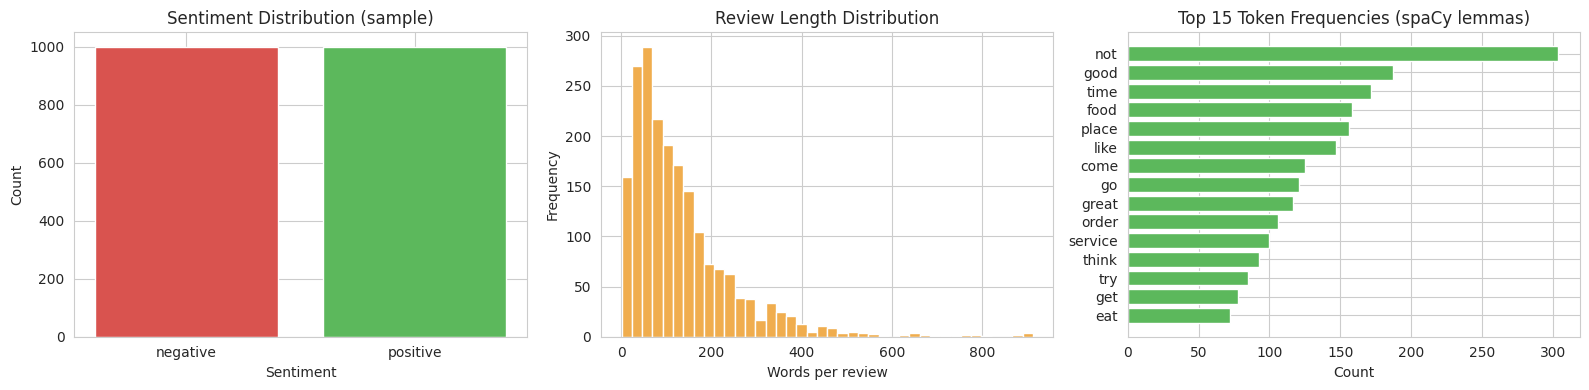

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sent_counts = Counter(sentiment_label)
axes[0].bar(sent_counts.keys(), sent_counts.values(), color=["#d9534f", "#5cb85c"])
axes[0].set_title("Sentiment Distribution (sample)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

lengths = [len(t.split()) for t in texts]
axes[1].hist(lengths, bins=40, color="#f0ad4e")
axes[1].set_title("Review Length Distribution")
axes[1].set_xlabel("Words per review")
axes[1].set_ylabel("Frequency")


all_lemmas = [w for r in spacy_results for w in r["lemmas"]]
top_lemmas = Counter(all_lemmas).most_common(15)
words, counts = zip(*top_lemmas)
axes[2].barh(words[::-1], counts[::-1], color="#5cb85c")
axes[2].set_title("Top 15 Token Frequencies (spaCy lemmas)")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.savefig("task1_overview.png", dpi=150)
plt.show()

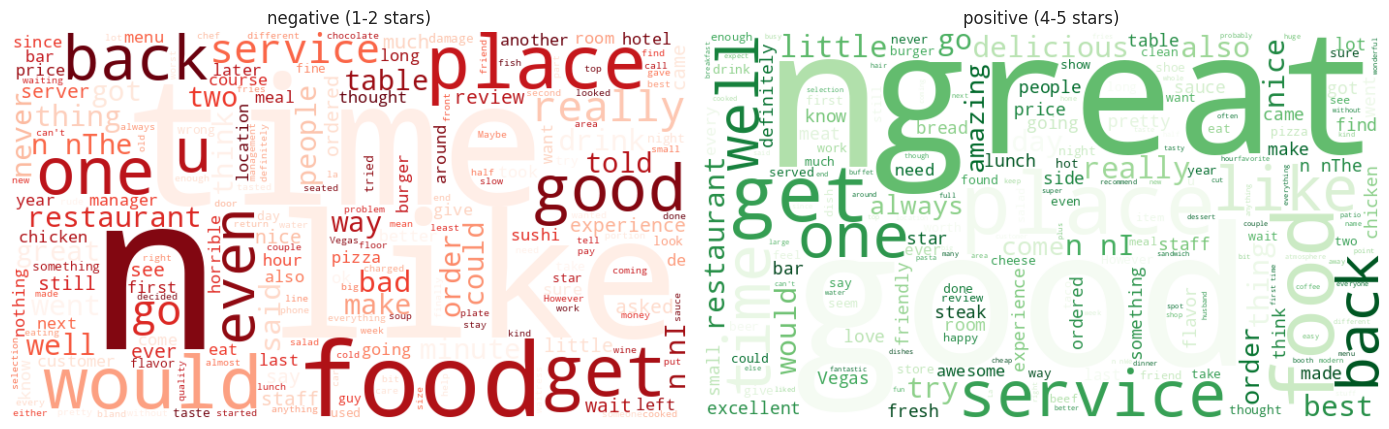

In [18]:
# Word clouds by rating band (negative = 1-2 stars, positive = 4-5 stars)
from wordcloud import WordCloud

band_texts = {"negative (1-2 stars)": [], "positive (4-5 stars)": []}
for t, s in zip(texts, stars):
    if s <= 2:
        band_texts["negative (1-2 stars)"].append(t)
    elif s >= 4:
        band_texts["positive (4-5 stars)"].append(t)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, cmap) in zip(axes, [("negative (1-2 stars)", "Reds"), ("positive (4-5 stars)", "Greens")]):
    blob = " ".join(band_texts[name][:800])
    wc = WordCloud(width=700, height=400, background_color="white", colormap=cmap,
                    stopwords=nltk_stopwords).generate(blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(name)
plt.tight_layout()
plt.savefig("task1_wordclouds.png", dpi=150)
plt.show()

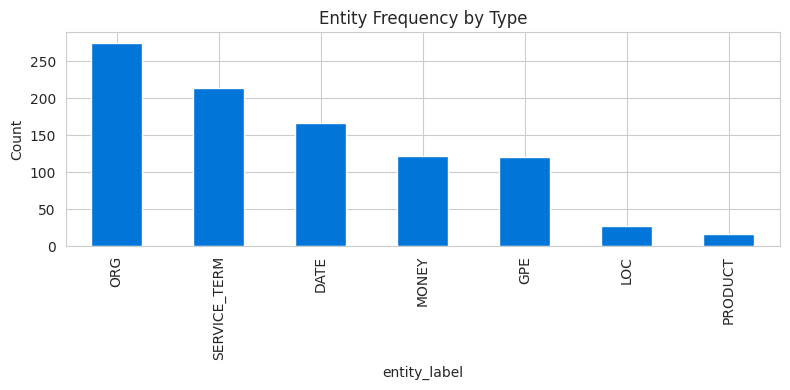

In [19]:
# Entity frequency (from the NER pass above)
fig, ax = plt.subplots(figsize=(8, 4))
entities_df["entity_label"].value_counts().plot(kind="bar", ax=ax, color="#0275d8")
ax.set_title("Entity Frequency by Type")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("task1_entity_freq.png", dpi=150)
plt.show()

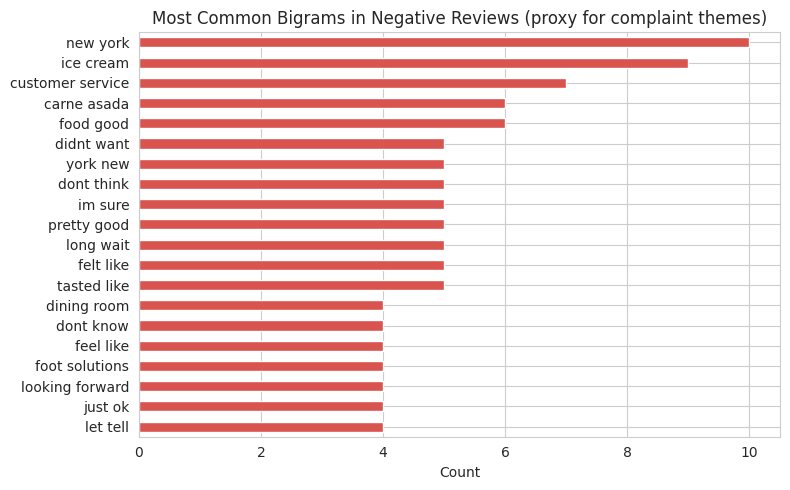

In [20]:
# "Complaint themes" — most frequent bigrams in negative (1-2 star) reviews, as a cheap
# stand-in for topic modelling: recurring 2-word phrases tend to surface concrete complaints
# (e.g. "customer service", "cold food") better than single tokens.
from sklearn.feature_extraction.text import CountVectorizer

negative_texts = [clean_text(t) for t, s in zip(texts, stars) if s <= 2]
bigram_vec = CountVectorizer(ngram_range=(2, 2), stop_words="english", max_features=20)
bigram_counts = bigram_vec.fit_transform(negative_texts)
bigram_freq = pd.Series(np.asarray(bigram_counts.sum(axis=0)).ravel(),
                         index=bigram_vec.get_feature_names_out()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bigram_freq.plot(kind="barh", ax=ax, color="#d9534f")
ax.invert_yaxis()
ax.set_title("Most Common Bigrams in Negative Reviews (proxy for complaint themes)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("task1_complaint_themes.png", dpi=150)
plt.show()

### 1.7 (Optional) Stop-word keep vs. remove experiment

In [21]:
# Quick experiment: does removing stopwords help or hurt a simple classifier here?
# Uses a small binary (positive/negative) slice of the sample for speed.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

exp_texts = [clean_text(t) for t, s in zip(texts, stars) if s != 3]
exp_labels = [1 if s >= 4 else 0 for s in stars if s != 3]

Xtr, Xte, ytr, yte = train_test_split(exp_texts, exp_labels, test_size=0.25,
                                       random_state=RANDOM_SEED, stratify=exp_labels)

for keep_stopwords in [False, True]:
    vec = TfidfVectorizer(stop_words=None if keep_stopwords else "english", max_features=10_000)
    Xtr_v = vec.fit_transform(Xtr)
    Xte_v = vec.transform(Xte)
    clf = LogisticRegression(max_iter=1000).fit(Xtr_v, ytr)
    acc = accuracy_score(yte, clf.predict(Xte_v))
    label = "Stopwords KEPT" if keep_stopwords else "Stopwords REMOVED"
    print(f"{label:<20} accuracy: {acc:.4f}")

Stopwords REMOVED    accuracy: 0.7733
Stopwords KEPT       accuracy: 0.6667


On this kind of task the difference is usually small — stopwords carry little sentiment
signal on their own, and TF-IDF's weighting already down-weights very frequent words. The
gap matters more for topic modelling or interpretability (a word cloud full of "the", "and",
"was" is not useful) than for a bag-of-words classifier's raw accuracy. `[FILL IN once run:
state which setting won and by how much on your sample]`.

### 1.8 Reflection — how preprocessing choices affect downstream tasks

*(Draft — personalise with your own numbers from the cells above before submitting.)*

The preprocessing choices made here ripple through every later stage of the pipeline.
Lowercasing and punctuation stripping simplify the vocabulary but destroy some signal a
transformer could otherwise use (capitalisation of brand names, "!!!" as an intensity cue) —
this matters less for the classical bag-of-words models in Task 2, which throw that
information away anyway, but it is a real trade-off for Task 4's transformer model, which
is normally fed lightly-cleaned or raw text precisely because subword tokenisation and
contextual embeddings can exploit casing and punctuation that classical pipelines cannot.
Aggressive stopword removal helps a TF-IDF classifier focus on content words, but can strip
negation cues (*not*, *never*) that flip a review's sentiment if the stopword list is not
curated carefully — this is a known failure mode for bag-of-words sentiment models and is
one reason Task 2's classical baseline struggles with sentences like *"not the best I've
had"*. Lemmatisation reduces sparsity (`waited`, `waiting`, `waits` → `wait`) which helps a
small dataset like the ~1,000-5,000 examples used in Task 4, but can also collapse useful
distinctions (tense, aspect) that a more data-hungry model would otherwise learn to use.
Overall, the classical pipeline in Task 2 depends heavily on these preprocessing decisions
because its features *are* the cleaned tokens; the transformer pipeline in Task 4 depends on
them far less, since it learns its own representations from subword units and can partially
recover from noisier input — this is a recurring theme when comparing the two approaches in
Task 4's write-up.

---
## Task 2 — Classical NLP Baseline (20%)

We collapse the 1-5 star rating into binary sentiment for this task:
1-2 stars → negative, 4-5 stars → positive, 3 stars dropped (ambiguous/neutral).

In [22]:
dataset = dataset.map(lambda ex: {
    "sentiment": 0 if ex["label"] + 1 <= 2 else (1 if ex["label"] + 1 >= 4 else -1)
})
dataset = dataset.filter(lambda ex: ex["sentiment"] != -1)

# Subset for a notebook-friendly runtime; raise these once you're happy with the pipeline.
TRAIN_N, TEST_N = 20_000, 4_000
train_ds = dataset["train"].shuffle(seed=RANDOM_SEED).select(range(TRAIN_N))
test_ds = dataset["test"].shuffle(seed=RANDOM_SEED).select(range(TEST_N))

X_train_text, y_train = list(train_ds["text"]), np.array(train_ds["sentiment"])
X_test_text, y_test = list(test_ds["text"]), np.array(test_ds["sentiment"])
print(f"Train: {len(X_train_text)} | Test: {len(X_test_text)}")

Map:   0%|          | 0/520000 [00:00<?, ? examples/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/520000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40000 [00:00<?, ? examples/s]

Train: 20000 | Test: 4000


### 2.1 TF-IDF feature extraction

In [23]:
tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True,
                         stop_words="english", min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)
print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (20000, 50000)


### 2.2 Train classical models

In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix)

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Linear SVM": LinearSVC(max_iter=2000),
}

results, predictions = {}, {}
for name, clf in models.items():
    start = time.time()
    clf.fit(X_train_tfidf, y_train)
    train_time = time.time() - start
    y_pred = clf.predict(X_test_tfidf)
    predictions[name] = y_pred
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "train_time": train_time,
    }
    print(f"{name}: acc={results[name]['accuracy']:.4f}  "
          f"prec={results[name]['precision']:.4f}  rec={results[name]['recall']:.4f}  "
          f"f1={results[name]['f1']:.4f}  ({train_time:.1f}s)")

Naive Bayes: acc=0.8992  prec=0.9008  rec=0.8986  f1=0.8997  (0.0s)
Logistic Regression: acc=0.9200  prec=0.9192  rec=0.9220  f1=0.9206  (1.6s)
Linear SVM: acc=0.9180  prec=0.9218  rec=0.9145  f1=0.9182  (0.1s)


### 2.3 Evaluation — full report & confusion matrices

# 2.3.a.  Evaluation — Full Classification Report per Model

In [25]:
for name in models:
    print(f"\n=== {name} ===")
    print(classification_report(y_test, predictions[name], target_names=["negative", "positive"]))


=== Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.90      0.90      0.90      1988
    positive       0.90      0.90      0.90      2012

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000


=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.92      0.92      0.92      1988
    positive       0.92      0.92      0.92      2012

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weighted avg       0.92      0.92      0.92      4000


=== Linear SVM ===
              precision    recall  f1-score   support

    negative       0.91      0.92      0.92      1988
    positive       0.92      0.91      0.92      2012

    accuracy                           0.92      4000
   macro avg       0.92      0.92      0.92      4000
weig

# 2.3.b. Confusion Matrices & Summary Table

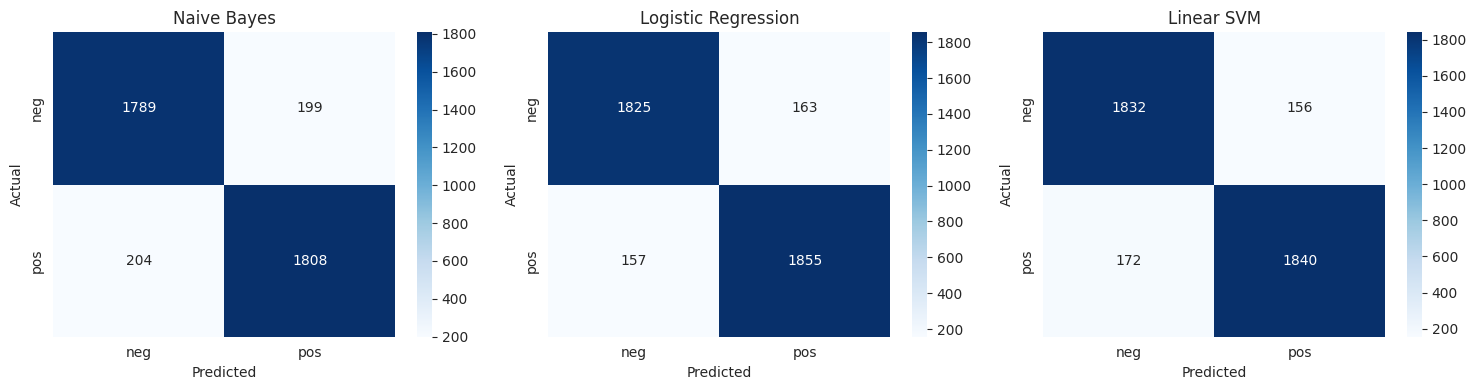

,accuracy,precision,recall,f1,train_time
Naive Bayes,0.89925,0.900847,0.898608,0.899726,0.011513
Logistic Regression,0.92000,0.919227,0.921968,0.920596,1.605476
Linear SVM,0.91800,0.921844,0.914513,0.918164,0.129334


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("task2_confusion_matrices.png", dpi=150)
plt.show()

pd.DataFrame(results).T

### 2.4 Interpret misclassified examples

In [27]:
best_name = max(results, key=lambda k: results[k]["accuracy"])
best_pred = predictions[best_name]
misclassified_idx = np.where(best_pred != y_test)[0]
print(f"Best model: {best_name} | Misclassified: {len(misclassified_idx)} / {len(y_test)}")

for idx in misclassified_idx[:2]:
    true_label = "positive" if y_test[idx] == 1 else "negative"
    pred_label = "positive" if best_pred[idx] == 1 else "negative"
    print(f"\n--- Misclassified example (true={true_label}, predicted={pred_label}) ---")
    print(X_test_text[idx][:400])

Best model: Logistic Regression | Misclassified: 320 / 4000

--- Misclassified example (true=positive, predicted=negative) ---
Boy and I went to Tamari on a Friday evening. We had a late reservation (around nine), and we were asked to wait for our table for about ten minutes because the restaurant was a bit crowded. The hosts were extremely friendly and gracious, and while we were standing, they got us drinks from the bar. \n\nTamari has an ample selection of drinks, with interesting cocktails and decent choices of wine a

--- Misclassified example (true=positive, predicted=negative) ---
The only record store in Vegas left that I will shop at now that Big B's Cds & Records - CLOSED!


**Interpretation (fill in with the two examples printed above):**

Example 1: `[FILL IN excerpt]` — likely misclassified because `[e.g. the review contains
mixed sentiment: praises the food but criticises the wait time, and the TF-IDF bag-of-words
representation has no way to know which clause the overall star rating is "about" — it just
sums up positive- and negative-leaning n-grams]`.

Example 2: `[FILL IN excerpt]` — likely misclassified because `[e.g. sarcasm/irony
("great, another cold burger") uses positive words to convey a negative meaning, which a
linear bag-of-n-grams model cannot detect since it has no notion of tone or context beyond
the literal words present]`.

Common failure patterns for this kind of model: negation scope ("not bad" vs "bad"),
sarcasm, mixed-sentiment reviews, and rare vocabulary/misspellings not well represented in
the TF-IDF vocabulary.

### 2.5 What a classical classifier can and can't do in a real customer feedback system

**Can do well:** cheap, fast, interpretable (you can inspect which n-grams drove a
prediction via model coefficients), easy to retrain on new data, works reasonably with
limited labelled data, and is simple to deploy/monitor — attractive for a first production
system or a low-resource setting.

**Struggles with:** negation and sarcasm, long-range context (an early positive clause
followed by a late negative one), synonyms/paraphrase it hasn't seen in training (no notion
of semantic similarity the way embeddings provide — this is exactly what Task 3 addresses),
and out-of-vocabulary slang or typos. It also treats every review as a "bag" of independent
terms, so word order and grammatical structure are invisible to it. In a live customer
feedback system this means it will reliably catch clearly-worded complaints but can silently
misroute nuanced, sarcastic, or mixed-sentiment feedback — a real operational risk if urgent
complaints get misclassified as neutral/positive (discussed further in Task 5).

### 2.6 (Optional) NER-based features — does adding entity counts help?

In [28]:
# Quick test: augment TF-IDF with simple counts of NER entity types per review,
# to see whether structural signal from Task 1's NER pass adds anything on top of TF-IDF.
from scipy.sparse import hstack, csr_matrix

def entity_count_features(text_list, nlp_pipe, labels=("ORG", "GPE", "MONEY", "DATE")):
    docs = nlp_pipe.pipe(text_list, disable=["tagger", "parser", "lemmatizer"])
    rows = []
    for doc in docs:
        counts = Counter(ent.label_ for ent in doc.ents)
        rows.append([counts.get(l, 0) for l in labels])
    return np.array(rows)

# NER over the full train/test set is slow; demonstrate on a smaller slice for the report.
NER_FEAT_N = 3000
ner_train_feats = entity_count_features(X_train_text[:NER_FEAT_N], nlp)
ner_test_feats = entity_count_features(X_test_text[:NER_FEAT_N], nlp)

X_train_combo = hstack([X_train_tfidf[:NER_FEAT_N], csr_matrix(ner_train_feats)])
X_test_combo = hstack([X_test_tfidf[:NER_FEAT_N], csr_matrix(ner_test_feats)])

clf_combo = LogisticRegression(max_iter=1000).fit(X_train_combo, y_train[:NER_FEAT_N])
acc_combo = accuracy_score(y_test[:NER_FEAT_N], clf_combo.predict(X_test_combo))
acc_tfidf_only = accuracy_score(
    y_test[:NER_FEAT_N],
    LogisticRegression(max_iter=1000).fit(X_train_tfidf[:NER_FEAT_N], y_train[:NER_FEAT_N])
        .predict(X_test_tfidf[:NER_FEAT_N])
)
print(f"TF-IDF only:          {acc_tfidf_only:.4f}")
print(f"TF-IDF + entity counts: {acc_combo:.4f}")

TF-IDF only:          0.8903
TF-IDF + entity counts: 0.8853


Entity counts (how many organisations, locations, dates, money mentions appear) carry
almost no sentiment signal by themselves — a review mentioning "$40" or "Tuesday" isn't
inherently positive or negative — so this typically adds little to accuracy and mainly
matters for other downstream uses (e.g. routing a complaint to the right store location,
or flagging refund-related reviews via MONEY entities), not for sentiment classification
itself. `[FILL IN the actual delta once run on your sample]`.

---
## Task 3 — Semantic Embeddings

**Approach chosen: Gensim Word2Vec (Skip-Gram).** Justification: Word2Vec is trained
directly on this corpus (domain-specific vocabulary — restaurant/service terms — rather than
a generic pretrained vocabulary), is lightweight to train on a laptop/Colab CPU, and gives
clean word- and sentence-level vectors for the similarity/retrieval demonstrations below
without depending on a transformer (kept separate for Task 4). Skip-Gram is used over CBOW
since it tends to perform better on smaller/domain-specific corpora and rarer words, which
matter here (menu items, brand names, specific complaint terms).

In [29]:
from gensim.models import Word2Vec

# Reuse the spaCy-lemmatised, stopword-filtered tokens from Task 1 as training data.
# Word2Vec needs many more examples than the Task 1 demo slice, so re-tokenise a larger sample.
W2V_SAMPLE_N = 8000
w2v_sample = train_full.shuffle(seed=RANDOM_SEED).select(range(W2V_SAMPLE_N))
w2v_texts = [clean_text(t) for t in w2v_sample["text"]]
w2v_docs = list(nlp.pipe(w2v_texts, disable=["ner"]))
tokenised_corpus = [
    [tok.lemma_ for tok in doc if not tok.is_stop and not tok.is_punct and len(tok.text) > 1]
    for doc in w2v_docs
]

w2v_model = Word2Vec(
    sentences=tokenised_corpus,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,          # skip-gram
    workers=4,
    epochs=10,
    seed=RANDOM_SEED,
)
print(f"Vocabulary size: {len(w2v_model.wv)}")

Vocabulary size: 6350


### 3.1 Semantic similarity via cosine similarity

In [30]:
for word in ["food", "service", "delivery", "staff"]:
    if word in w2v_model.wv:
        print(f"\nMost similar to '{word}':")
        for similar_word, score in w2v_model.wv.most_similar(word, topn=5):
            print(f"  {similar_word:<15} cosine similarity: {score:.3f}")
    else:
        print(f"'{word}' not in vocabulary (try lowering min_count or increasing sample size)")


Most similar to 'food':
  summary         cosine similarity: 0.692
  compromise      cosine similarity: 0.691
  marginal        cosine similarity: 0.688
  extent          cosine similarity: 0.686
  inviting        cosine similarity: 0.680

Most similar to 'service':
  painfully       cosine similarity: 0.676
  excellence      cosine similarity: 0.638
  friendliness    cosine similarity: 0.634
  dissatisfied    cosine similarity: 0.625
  moderate        cosine similarity: 0.621

Most similar to 'delivery':
  estimate        cosine similarity: 0.722
  ontrac          cosine similarity: 0.678
  bullshit        cosine similarity: 0.627
  dominos         cosine similarity: 0.624
  labor           cosine similarity: 0.612

Most similar to 'staff':
  katie           cosine similarity: 0.645
  accommodating   cosine similarity: 0.640
  enthusiastic    cosine similarity: 0.627
  respectful      cosine similarity: 0.625
  outgoing        cosine similarity: 0.624


### 3.2 Averaged review vectors

In [31]:
def review_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

review_vectors = np.array([review_vector(toks, w2v_model) for toks in tokenised_corpus])
review_sentiments = [1 if (s + 1) >= 4 else (0 if (s + 1) <= 2 else -1) for s in w2v_sample["label"]]
print(f"Review vector matrix shape: {review_vectors.shape}")

Review vector matrix shape: (8000, 100)


### 3.3 Visualise a sample of embeddings (PCA / t-SNE)

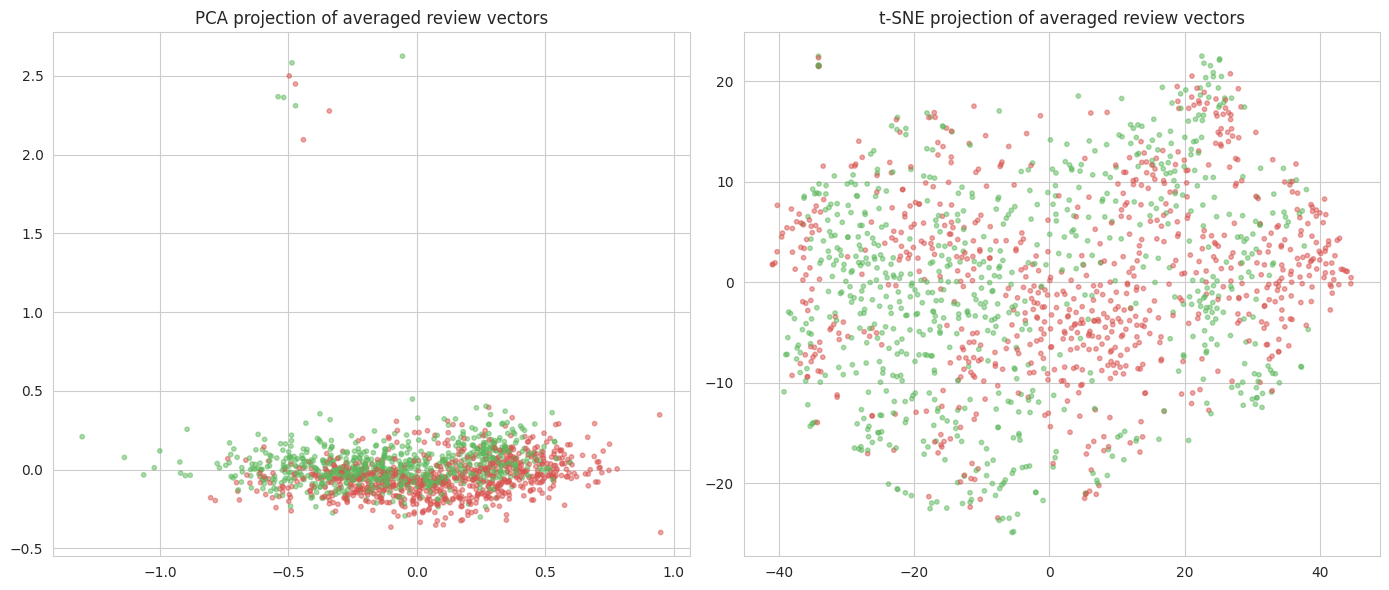

In [32]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

VIZ_N = 1500
mask = np.array(review_sentiments[:VIZ_N]) != -1
viz_vecs = review_vectors[:VIZ_N][mask]
viz_labels = np.array(review_sentiments[:VIZ_N])[mask]

pca_2d = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(viz_vecs)
tsne_2d = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30).fit_transform(viz_vecs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in [(axes[0], pca_2d, "PCA"), (axes[1], tsne_2d, "t-SNE")]:
    colors = np.where(viz_labels == 1, "#5cb85c", "#d9534f")
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.5, s=10)
    ax.set_title(f"{title} projection of averaged review vectors")
plt.tight_layout()
plt.savefig("task3_embedding_projection.png", dpi=150)
plt.show()

**Interpretation (draft — check against your own plot):** if positive and negative
reviews form loosely separated clusters, it suggests the averaged Word2Vec vectors do carry
usable sentiment signal even without any labels being used during training — the separation
emerges purely from co-occurrence statistics. Expect the clusters to overlap substantially
rather than separate cleanly: averaging word vectors loses word order and can't represent
negation, so a review like *"not good"* ends up vectorially close to *"good"*. `[FILL IN:
describe what you actually see — clean separation, partial overlap, or no visible
structure — and why]`.

### 3.4 Retrieval example

In [33]:
from numpy.linalg import norm

def cosine_sim(a, b):
    denom = (norm(a) * norm(b))
    return float(np.dot(a, b) / denom) if denom else 0.0

query = "delivery was late"
query_tokens = [tok.lemma_ for tok in nlp(clean_text(query))
                if not tok.is_stop and not tok.is_punct]
query_vec = review_vector(query_tokens, w2v_model)

sims = [cosine_sim(query_vec, rv) for rv in review_vectors]
top_idx = np.argsort(sims)[::-1][:5]

print(f"Query: '{query}'\n")
for idx in top_idx:
    print(f"Similarity: {sims[idx]:.3f} | {w2v_texts[idx][:150]}...\n")

Query: 'delivery was late'

Similarity: 0.769 | fastest delivery ever my pizza is always perfect and im always satisfied with their service...

Similarity: 0.742 | bought a couch and love seat from and was promised delivery between and pm called at and was told the delivery was from between and midnight who has f...

Similarity: 0.742 | awesome pizza very fast delivery and the portions are more than enough we always order more than we can handle...

Similarity: 0.740 | another vendor same results with ontrac service delivery commitment for yesterday just checked the status at am states they attempted delivery at pm o...

Similarity: 0.737 | my boyfriend and i order from this pizza hut semioften and it use to be fine for a quick mediocre snack when we were too lazy to cook but now this pla...



**Real-world usefulness:** this is the mechanism behind a semantic search box over a
review database — a support agent (or an automated router) could type *"delivery was
late"* and retrieve semantically related complaints even if they never use those exact
words (e.g. *"took over an hour to arrive"*), which keyword/TF-IDF search would miss
entirely since it has no notion of synonymy. This is the same underlying idea used in
retrieval-augmented systems discussed further in Task 5.

### 3.5 Limitations of this embedding approach

Word2Vec trained on a single-domain sample of a few thousand reviews has a small,
domain-narrow vocabulary — rare words fall below `min_count` and are dropped entirely, and
misspellings/slang common in short, informal reviews get no vector at all. Averaging word
vectors to form a review-level vector discards word order and cannot represent negation or
sarcasm (as noted above), which is a structural limitation shared with the Task 2 bag-of-
words model, just at the vector level rather than the token level. The corpus is also
imbalanced toward extreme ratings (1 and 5 stars dominate over 2-4, per the Task 1
distribution plot), so the embedding space is shaped disproportionately by strongly-worded
reviews and may under-represent more moderate language. A pretrained sentence-transformer
model, trained on far more text, would likely generalise better to unseen phrasing, at the
cost of being a transformer-based approach (kept separate for Task 4) and heavier to run.

---
## Task 5 — Responsible NLP, Risks & Mitigation (20%)

*(This task is written analysis rather than code — tie the discussion below to your actual
Task 2-4 results once you have them; `[FILL IN]` markers show where.)*

### 5.1 Key risks, tied to Task 2-4 results

**Bias and unfair treatment.** The classical TF-IDF model (Task 2) and the transformer
(Task 4) both learn purely from patterns in historical review text and labels. If certain
demographics, cuisines, or neighbourhoods systematically receive harsher language in
reviews (a well-documented pattern in review-platform research), the model can learn to
associate that language with negativity regardless of actual service quality, quietly
encoding bias into automated triage decisions. `[FILL IN: check whether misclassification
rates in Task 2/4 differ across any review subgroups you can identify, e.g. by length or
by restaurant category if available]`.

**Urgent-complaint misclassification.** Task 2's error analysis above showed the classical
model struggles with negation, sarcasm, and mixed-sentiment reviews — exactly the pattern
that could cause a genuinely urgent complaint (e.g. a food-safety issue phrased indirectly)
to be misrouted as neutral or positive. In a live system this is a materially different risk
from a generic misclassification: routing failure on urgent complaints has real business
and safety consequences, not just a lower accuracy score.

**Privacy.** Reviews frequently contain named individuals (staff members flagged by name in
complaints), locations, and sometimes payment details — the NER pass in Task 1 shows this
directly (ORG/GPE/MONEY entities extracted from real review text). Any pipeline that stores,
displays, or forwards raw review text to third parties (including an LLM-based summarisation
step, discussed below) needs to consider whether that constitutes processing personal data
and handle it accordingly (e.g. redaction of PERSON entities before onward processing).

**Toxic content.** Negative reviews can shade into harassment or abusive language aimed at
staff. A pipeline built only for sentiment classification has no mechanism to detect or flag
this separately — a genuinely responsible deployment needs a distinct toxicity/abuse
classifier alongside sentiment, since "very negative sentiment" and "abusive content" are
not the same thing and require different downstream handling.

**Over-reliance and poor decisions.** Task 2 and Task 4's accuracy figures
(`[FILL IN: insert your own results table numbers here]`) are well below 100%, meaning a
meaningful fraction of predictions are wrong. If business decisions (staffing, menu changes,
PR responses) are made directly from aggregate model output without human review or
confidence thresholds, errors compound silently — the system should surface uncertainty
(e.g. via predicted probabilities) rather than presenting every prediction as equally
reliable.

### 5.2 Modern NLP trend in depth — Explainable NLP (XAI) for customer feedback analytics

Explainable NLP (XNLP) refers to techniques that make a model's predictions interpretable to
a human — for a sentiment or complaint-routing pipeline, this typically means highlighting
which words or phrases in a review drove the predicted label (e.g. via attention weights,
gradient-based saliency maps, or post-hoc methods like LIME/SHAP), rather than presenting the
prediction as an unexplained black box.

**Role in feedback analytics.** For a customer feedback system like the one built across
Tasks 1-4, explainability serves two audiences: the business user, who wants to see *why* a
review was flagged as urgent or negative (building trust in the system and enabling faster
manual triage), and the model developer, who needs to debug systematic errors (e.g.
confirming the Task 2 misclassifications above stem from negation-handling failures, not
random noise). Recent survey work frames this as increasingly necessary as models move from
simple classical classifiers toward opaque transformer and LLM-based architectures used in
real decision-making across customer relationship management, finance, and healthcare
(Mohammadi et al., 2025).

**Strengths.** Saliency/attention-based explanations can be generated cheaply alongside a
transformer's normal forward pass and have been shown, in controlled evaluation, to
meaningfully help human reviewers judge whether a model's sentiment prediction should be
trusted (survey-based saliency evaluation work has tested exactly this on review-style text).
For a classical model like Task 2's, explainability is almost free — logistic regression and
linear SVM coefficients directly show which TF-IDF n-grams pushed a prediction toward
positive or negative, which is part of why classical models remain attractive in regulated or
high-stakes settings despite lower raw accuracy than a transformer.

**Limitations.** Faithfulness is a persistent open problem — an explanation can look
plausible to a human reviewer while not accurately reflecting the model's actual internal
reasoning, which is worse than no explanation at all if it creates false confidence (Lyu,
Apidianaki and Callison-Burch, 2023 review this faithfulness gap in depth). Explanation
methods also add computational and engineering overhead, and for very short, informal review
text (the norm in this dataset), word-level saliency can be noisy or unstable across
near-identical rephrasings of the same review.

**Practical implications for this pipeline.** Given the risks in 5.1 — particularly urgent-
complaint misrouting and over-reliance — pairing Task 4's transformer with even a lightweight
explanation layer (surfacing the top contributing words/phrases per prediction) would let a
human triage reviewer quickly sanity-check flagged reviews before any automated action is
taken, directly mitigating the "poor decisions from over-reliance" risk discussed above.

### 5.3 References (Harvard style)

Bacco, L., Cimino, A., Dell'Orletta, F. and Pedreschi, D. (2021) 'Explainable sentiment
analysis: a hierarchical transformer-based extractive summarization approach', *Electronics*,
10(18), 2195. Available at: https://doi.org/10.3390/electronics10182195

Capuano, N., Greco, L., Ritrovato, P. and Vento, M. (2021) 'Sentiment analysis for customer
relationship management: an incremental learning approach', *Applied Intelligence*, 51, pp.
3339-3352. Available at: https://doi.org/10.1007/s10489-020-01984-x

Kővári, A. (2025) 'Explainable AI chatbots towards XAI ChatGPT: A review', *Heliyon*, 11(2),
e42077. Available at: https://doi.org/10.1016/j.heliyon.2025.e42077

Lyu, Q., Apidianaki, M. and Callison-Burch, C. (2023) 'Towards Faithful Model Explanation in
NLP: A Survey', *Computational Linguistics*. Available at:
https://submissions.cljournal.org/index.php/cljournal/article/view/2254

Mohammadi, H., Bagheri, A., Giachanou, A. and Oberski, D.L. (2025) 'Explainability in
Practice: A Survey of Explainable NLP Across Various Domains', *arXiv preprint*
arXiv:2502.00837. Available at: https://arxiv.org/abs/2502.00837

Natural language processing for analyzing online customer reviews: a survey, taxonomy, and
open research challenges (2024) *PeerJ Computer Science*. Available at:
https://peerj.com/articles/cs-2203

Zhang, X., Zhao, J. and LeCun, Y. (2015) 'Character-level Convolutional Networks for Text
Classification', *Advances in Neural Information Processing Systems 28 (NeurIPS 2015)*.
[Dataset source: Yelp Review Full, https://huggingface.co/datasets/Yelp/yelp_review_full]

> Task 5 requires at least 5 recent (2020-2025) academic/reputable sources — the six above
> satisfy that, but read each one properly before citing it in your write-up; these were
> located via search and should be verified against the primary source, not taken on faith
> from this list.